# E3 — PoinTr v5: ablación de datasets

Notebook parametrizado para comparar combinaciones de datasets.  
**Solo cambia la Celda 3 entre experimentos.**

| Flag | Dataset | Pares aprox. | Estado |
|------|---------|-------------|--------|
| `USAR_FB_V2` | Fantastic Breaks v2 | 61 | ✅ Rocío-cleaned |
| `USAR_OBJAVERSE` | Objaverse v2 | ? | ✅ Rocío-cleaned |
| `USAR_SHAPENET` | ShapeNet roturas | ? | ⚠️ Parcialmente limpio |

**Experimentos sugeridos (en orden):**
1. `FB=T OBJ=T SN=F` → v5_fb_obj — datos reales limpios
2. `FB=F OBJ=T SN=F` → v5_obj — Objaverse solo (baseline)
3. `FB=T OBJ=T SN=T` → v5_all — todo junto

**Referencia:** PoinTr v4 (solo FB v2): CD=0.0569, F=0.0285 | PoinTr v2 (mix): CD=0.0533, F=0.3278

In [1]:
# ── CELDA 1: Montar Drive ──────────────────────────────────────
from google.colab import drive
import os
if os.path.isdir('/content/drive') and os.listdir('/content/drive'):
    print('Drive ya montado.')
else:
    drive.mount('/content/drive')
    print('Drive montado.')

Mounted at /content/drive
Drive montado.


In [2]:
# ── CELDA 2: Clonar repos + instalar dependencias ──────────────
import os, subprocess
from getpass import getpass

if not os.path.exists('/content/PoinTr'):
    subprocess.run(['git','clone','https://github.com/yuxumin/PoinTr',
                    '/content/PoinTr','--depth=1','-q'], capture_output=True)
    print('PoinTr clonado.')
else:
    print('[OK] /content/PoinTr ya existe.')

REPO_DIR = '/content/TFM'
if not os.path.exists(REPO_DIR):
    token = getpass('Token GitHub (ghp_...): ')
    subprocess.run(['git','clone',f'https://{token}@github.com/herredoble/TFM-reconstruccion-3D',
                    REPO_DIR,'-q'], capture_output=True)
    del token; print('Repo TFM clonado.')
else:
    subprocess.run(['git','-C',REPO_DIR,'pull','-q'], capture_output=True)
    print('[OK] /content/TFM actualizado.')

os.chdir(REPO_DIR)
subprocess.run(['git','checkout','raquel/e3','-q'], capture_output=True)
subprocess.run(['pip','install','timm','easydict','pyyaml','--quiet'])
print('[OK] timm easydict pyyaml')

for ext_name, ext_path in [
    ('pointnet2_ops', '/content/PoinTr/extensions/pointnet2_ops_lib'),
    ('chamfer_dist',  '/content/PoinTr/extensions/chamfer_dist'),
]:
    r = subprocess.run(['pip','install','-e',ext_path,'--quiet'], capture_output=True, text=True)
    print(f'[{"OK" if r.returncode==0 else "WARN fallback"}] {ext_name}')

PoinTr clonado.
Token GitHub (ghp_...): ··········
Repo TFM clonado.
[OK] timm easydict pyyaml
[WARN fallback] pointnet2_ops
[OK] chamfer_dist


In [3]:
# ══════════════════════════════════════════════════════════════
# CELDA 3 — CONFIGURACION  (solo cambia esto entre experimentos)
# ══════════════════════════════════════════════════════════════

USAR_FB_V2      = True   # Fantastic Breaks v2  — datos reales, Rocío-cleaned
USAR_OBJAVERSE  = True   # Objaverse v2         — Rocío-cleaned
USAR_SHAPENET   = False  # ShapeNet roturas     — parcialmente limpio

EPOCHS = 300
LR     = 1e-4
BATCH  = 32

# ── VERSION se genera sola ─────────────────────────────────────
_partes = []
if USAR_FB_V2:      _partes.append('fb')
if USAR_OBJAVERSE:  _partes.append('obj')
if USAR_SHAPENET:   _partes.append('sn')
if not _partes:
    raise ValueError('Activa al menos un dataset (USAR_FB_V2 / USAR_OBJAVERSE / USAR_SHAPENET)')
VERSION = 'v5_' + '_'.join(_partes)

print(f'VERSION : {VERSION}')
print(f'Datasets: {_partes}')
print(f'Epochs  : {EPOCHS}  LR={LR}  Batch={BATCH}')

VERSION : v5_fb_obj
Datasets: ['fb', 'obj']
Epochs  : 300  LR=0.0001  Batch=32


In [4]:
# ── CELDA 4: Rutas y verificación ──────────────────────────────
from pathlib import Path

DRIVE        = '/content/drive/MyDrive'
BASE_E3      = f'{DRIVE}/Datos_E2_E3/E3/Raquel'
BASE_GENERAL = f'{DRIVE}/Datos_E2_E3/General'

# Mapeo: clave → (ruta_drive, ruta_local)
FUENTES_TODAS = {
    'fb':  (f'{BASE_GENERAL}/Fantastik_Break_Procesado_v2',
            'Datos/fantastic_breaks/procesado_v2'),
    'obj': (f'{BASE_GENERAL}/roturas_Objaverse_v2',
            'Datos/objaverse/roturas_v2'),
    'sn':  (f'{BASE_GENERAL}/shapenet_roturas',
            'Datos/shapenet/roturas'),
}

FUENTES_ACTIVAS = {k: v for k, v in FUENTES_TODAS.items() if k in _partes}

RUTA_SALIDA_MODELO     = f'{BASE_E3}/modelos/{VERSION}'
RUTA_SALIDA_RESULTADOS = f'{BASE_E3}/resultados/{VERSION}'

print(f'Rutas activas para {VERSION}:')
ok_todos = True
for clave, (drive_path, local_path) in FUENTES_ACTIVAS.items():
    existe = Path(drive_path).exists()
    n = 0
    if existe:
        n = len(list(Path(drive_path).glob('*_completo.npy')))
    estado = f'OK — {n} pares' if existe else 'FALTA — revisa el nombre de la carpeta'
    print(f'  [{"OK" if existe else "!!"}] {clave}: {drive_path}')
    print(f'        {estado}')
    if not existe: ok_todos = False

if not ok_todos:
    print('\n⚠️  Algunas carpetas no existen. Comprueba los nombres y ajusta FUENTES_TODAS si hace falta.')
else:
    print('\n[OK] Todas las rutas verificadas.')

Rutas activas para v5_fb_obj:
  [OK] fb: /content/drive/MyDrive/Datos_E2_E3/General/Fantastik_Break_Procesado_v2
        OK — 60 pares
  [OK] obj: /content/drive/MyDrive/Datos_E2_E3/General/roturas_Objaverse_v2
        OK — 397 pares

[OK] Todas las rutas verificadas.


In [5]:
# ── CELDA 5: Copiar datos desde Drive ──────────────────────────
import subprocess
from pathlib import Path

for clave, (drive_path, local_path) in FUENTES_ACTIVAS.items():
    dst = Path(local_path)
    if dst.exists() and any(dst.glob('*.npy')):
        n = len(list(dst.glob('*.npy')))
        print(f'[OK] {clave} ya existe localmente ({n} .npy)')
        continue
    if not Path(drive_path).exists():
        print(f'[SKIP] {clave}: ruta Drive no encontrada — {drive_path}')
        continue
    dst.mkdir(parents=True, exist_ok=True)
    print(f'Copiando {clave}...')
    r = subprocess.run(['rsync','-a','--no-links',f'{drive_path}/',str(dst)],
                       capture_output=True, text=True)
    if r.returncode != 0:
        print(f'  [ERROR rsync] {r.stderr[:200]}')
    else:
        n = len(list(dst.glob('*.npy')))
        print(f'  listo — {n} archivos .npy')

Copiando fb...
  listo — 120 archivos .npy
Copiando obj...
  listo — 794 archivos .npy


In [6]:
# ── CELDA 6: Verificar GPU ─────────────────────────────────────
import torch
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('⚠️  Sin GPU — cambia a T4/A100')

GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB


In [7]:
# ── CELDA 7: ENTRENAR ──────────────────────────────────────────
import sys, os, math, time, types, glob as _glob, shutil, random, json
from pathlib import Path
from datetime import date

sys.path.insert(0, '/content/PoinTr')
sys.path.insert(0, '/content/TFM')
os.chdir('/content/TFM')

import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from easydict import EasyDict

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DEVICE_STR = str(device)
print(f'Dispositivo: {device}')
if device.type == 'cpu':
    raise SystemExit('Sin GPU — cambia a T4/A100')

# ── Reset cache PoinTr ───────────────────────────────────────
_pfx = ('models','utils.registry','utils.config','utils.logger','utils.misc','extensions')
_del = [k for k,v in sys.modules.items()
        if any(k==p or k.startswith(p+'.') for p in _pfx)
        or (hasattr(v,'__file__') and v.__file__ and '/content/PoinTr' in str(v.__file__))]
for k in _del: del sys.modules[k]
print(f'[reset] {len(_del)} modulos PoinTr')

# ── Patch .cuda() ────────────────────────────────────────────
_np = 0
for fp in _glob.glob('/content/PoinTr/models/*.py')+_glob.glob('/content/PoinTr/models/**/*.py'):
    try:
        src = open(fp, encoding='utf-8').read()
        new = src.replace('.cuda()', f'.to("{DEVICE_STR}")')
        if new != src: open(fp,'w',encoding='utf-8').write(new); _np+=1
    except: pass
print(f'[patch] {_np} archivos')

# ── Mocks CUDA ───────────────────────────────────────────────
def _force(name, attrs):
    m = types.ModuleType(name)
    for k,v in attrs.items(): setattr(m,k,v)
    sys.modules[name] = m

def _inject(name, attrs):
    if name not in sys.modules: _force(name, attrs)

def _chamfer_raw(a,b):
    d=torch.cdist(a,b,p=2); return d.min(2).values, d.min(1).values

class _ChamferL1(nn.Module):
    def forward(self,a,b):
        d1,d2=_chamfer_raw(a.contiguous(),b.contiguous()); return (d1.mean()+d2.mean())/2
class _ChamferL2(nn.Module):
    def forward(self,a,b):
        d1,d2=_chamfer_raw(a.contiguous(),b.contiguous()); return ((d1**2).mean()+(d2**2).mean())/2
class _ChamferL1_PM(nn.Module):
    def forward(self,a,b): return torch.cdist(a.contiguous(),b.contiguous(),p=2).min(2).values.mean()

_ch={'ChamferDistanceL1':_ChamferL1,'ChamferDistanceL2':_ChamferL2,
     'ChamferDistanceL1_PM':_ChamferL1_PM,'chamfer_3DDist':_chamfer_raw}
for n in ['chamfer','chamfer_dist','extensions.chamfer_dist','chamfer3D','chamfer3D.dist_chamfer_3D']:
    _force(n,_ch)
print('[OK] Mock chamfer')

if 'pointnet2_ops' not in sys.modules:
    def _fps(xyz,np_):
        B,N,_=xyz.shape; dev=xyz.device
        idx=torch.zeros(B,np_,dtype=torch.int32,device=dev)
        dist=torch.full((B,N),1e10,device=dev)
        far=torch.randint(0,N,(B,),dtype=torch.long,device=dev)
        bi=torch.arange(B,dtype=torch.long,device=dev)
        for i in range(np_):
            idx[:,i]=far.int(); c=xyz[bi,far].unsqueeze(1)
            dist=torch.min(dist,((xyz-c)**2).sum(-1)); far=dist.max(-1)[1]
        return idx
    def _go(f,idx): B,C,N=f.shape; M=idx.shape[1]; return f.gather(2,idx.long().unsqueeze(1).expand(B,C,M)).contiguous()
    def _bq(r,ns,xyz,nxyz):
        d=torch.cdist(nxyz.float(),xyz.float()); s=d.argsort(-1)[:,:,:ns]
        return torch.where(d.gather(2,s)>r,s[:,:,:1].expand_as(s),s).int()
    def _grp(f,idx):
        B,C,N=f.shape; S,K=idx.shape[1],idx.shape[2]
        return f.gather(2,idx.long().view(B,1,S*K).expand(B,C,S*K)).view(B,C,S,K).contiguous()
    def _3nn(u,k): d=torch.cdist(u.float(),k.float()); d2,i=d.topk(3,-1,largest=False); return d2.float(),i.int()
    def _3i(f,idx,w):
        B,C,M=f.shape; N=idx.shape[1]
        return (f.gather(2,idx.long().view(B,1,N*3).expand(B,C,N*3)).view(B,C,N,3)*w.unsqueeze(1)).sum(-1).contiguous()
    _pu=types.ModuleType('pointnet2_ops.pointnet2_utils')
    for k,v in {'furthest_point_sample':_fps,'gather_operation':_go,'ball_query':_bq,
                'grouping_operation':_grp,'three_nn':_3nn,'three_interpolate':_3i}.items(): setattr(_pu,k,v)
    _pm=types.ModuleType('pointnet2_ops'); _pm.pointnet2_utils=_pu
    sys.modules['pointnet2_ops']=_pm; sys.modules['pointnet2_ops.pointnet2_utils']=_pu
    print('[OK] Mock pointnet2_ops')

class _KNN(nn.Module):
    def __init__(self,k,transpose_mode=False): super().__init__(); self.k=k; self.tm=transpose_mode
    def forward(self,ref,query):
        if self.tm: d=torch.cdist(query.float(),ref.float()); dk,ik=d.topk(self.k,-1,largest=False); return dk,ik
        r=ref.transpose(1,2).contiguous(); q=query.transpose(1,2).contiguous()
        d=torch.cdist(q.float(),r.float()); dk,ik=d.topk(self.k,-1,largest=False)
        return dk.transpose(1,2),ik.transpose(1,2)
_force('knn_cuda',{'KNN':_KNN})

def _dc(n): return type(n,(nn.Module,),{'__init__':lambda s,*a,**k:super(type(s),s).__init__(),'forward':lambda s,x,*a,**k:x})
class _Emd(nn.Module):
    def forward(self,a,b): return torch.zeros(a.shape[0],device=a.device),torch.zeros(a.shape[0],dtype=torch.int32,device=a.device)
for base,attrs in [('gridding',{'Gridding':_dc('G'),'GriddingReverse':_dc('GR')}),
                   ('gridding_loss',{'GriddingLoss':_dc('GL')}),
                   ('cubic_feature_sampling',{'CubicFeatureSampling':_dc('CFS')}),
                   ('emd',{'emd_module':_Emd,'EarthMoverDistance':_Emd})]:
    for pfx in ['','extensions.']: _inject(pfx+base,attrs)
print('[OK] Mocks restantes')

from extensions.chamfer_dist import ChamferDistanceL1 as _CDL1
_cd_fn=_CDL1()
def chamfer_distance(p,g): return _cd_fn(p.contiguous(),g.contiguous())
def subsample_gt(gt,n): return gt[:,torch.randperm(gt.size(1),device=gt.device)[:n],:]

# ── Config y modelo ──────────────────────────────────────────
import yaml
cfg_path='/content/PoinTr/cfgs/PCN_models/PoinTr.yaml'
if not os.path.exists(cfg_path):
    cands=_glob.glob('/content/PoinTr/cfgs/**/PoinTr.yaml',recursive=True)
    cfg_path=cands[0] if cands else None
if cfg_path and os.path.exists(cfg_path):
    with open(cfg_path) as f: raw=yaml.safe_load(f)
    model_cfg=EasyDict(raw.get('model',raw))
else:
    model_cfg=EasyDict({'NAME':'PoinTr'})
model_cfg.num_pred=2048; model_cfg.num_query=128

try:
    from models.build import build_model_from_cfg; model=build_model_from_cfg(model_cfg)
except Exception as e1:
    from models.PoinTr import PoinTr; model=PoinTr(model_cfg)
model=model.to(device)
print(f'Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

# ── Dataset: combinar fuentes activas ────────────────────────
from E3.dataset import construir_pares, ShapeCompletionDataset
import E3.dataset as _ds
_ds.CENTRAR_EN_ROTO=False

carpetas_locales=[v[1] for v in FUENTES_ACTIVAS.values() if Path(v[1]).exists()]
if not carpetas_locales:
    raise RuntimeError('No hay datos locales — ejecuta Celda 5 primero')

_todos=construir_pares(carpetas_locales)
print(f'Total pares: {len(_todos)} (de {carpetas_locales})')

_rng=random.Random(42); _rng.shuffle(_todos); _n=len(_todos)
_nt=int(0.8*_n); _nv=int(0.1*_n)
_tr=_todos[:_nt]; _va=_todos[_nt:_nt+_nv]; _te=_todos[_nt+_nv:]
print(f'  Train:{len(_tr)} Val:{len(_va)} Test:{len(_te)}')

train_loader=DataLoader(ShapeCompletionDataset(_tr,augmentar=True), batch_size=BATCH,shuffle=True,pin_memory=True)
val_loader  =DataLoader(ShapeCompletionDataset(_va,augmentar=False),batch_size=BATCH,shuffle=False,pin_memory=True)
test_loader =DataLoader(ShapeCompletionDataset(_te,augmentar=False),batch_size=BATCH,shuffle=False,pin_memory=True)
print(f'Batches: train={len(train_loader)} val={len(val_loader)} test={len(test_loader)}')

# ── Hyperparams y resume ─────────────────────────────────────
CKPT_DIR=Path(f'E3/checkpoints_pointr_{VERSION}'); CKPT_DIR.mkdir(parents=True,exist_ok=True)
optimizer=AdamW(model.parameters(),lr=LR,weight_decay=5e-4)
scheduler=CosineAnnealingLR(optimizer,T_max=EPOCHS,eta_min=1e-6)
mejor_val=math.inf; train_losses=[]; val_losses=[]; START_EPOCH=1

def _find_latest_ckpt():
    dc=sorted(Path(RUTA_SALIDA_MODELO).glob('epoch_*.pt')) if Path(RUTA_SALIDA_MODELO).exists() else []
    lc=sorted(CKPT_DIR.glob('epoch_*.pt'))
    all_c=dc+lc
    if not all_c: return None
    def _ep(p):
        try: return int(p.stem.split('_')[1])
        except: return 0
    return max(all_c,key=_ep)

latest=_find_latest_ckpt()
if latest:
    print(f'Reanudando desde: {latest}')
    ck=torch.load(latest,map_location=device,weights_only=False)
    model.load_state_dict(ck['model_state_dict'])
    optimizer.load_state_dict(ck['optimizer_state_dict'])
    train_losses=ck.get('train_losses',[]); val_losses=ck.get('val_losses',[])
    START_EPOCH=ck['epoch']+1; mejor_val=min(val_losses) if val_losses else math.inf
    for _ in range(START_EPOCH-1): scheduler.step()
    print(f'  Desde {START_EPOCH}/{EPOCHS} | mejor val={mejor_val:.6f}')
else:
    print('Entrenamiento desde epoca 1')

if START_EPOCH>EPOCHS:
    print(f'Entrenamiento ya completo ({EPOCHS} epocas).')
    db=Path(RUTA_SALIDA_MODELO)/'best.pt'; lb=CKPT_DIR/'best.pt'
    if not lb.exists() and db.exists(): shutil.copy2(db,lb); print(f'[OK] best.pt copiado')
    print('Pasa a Celda 9.'); raise SystemExit('Completado.')

def guardar_ckpt(nombre,epoch):
    data={'epoch':epoch,'model_state_dict':model.state_dict(),
          'optimizer_state_dict':optimizer.state_dict(),
          'train_losses':train_losses,'val_losses':val_losses,'model_cfg':dict(model_cfg)}
    lp=CKPT_DIR/nombre; torch.save(data,lp)
    try:
        Path(RUTA_SALIDA_MODELO).mkdir(parents=True,exist_ok=True)
        shutil.copy2(lp,Path(RUTA_SALIDA_MODELO)/nombre)
    except Exception as e: print(f'  [WARN Drive] {e}')

print(f'\n{"Epoca":>7}  {"Train":>10}  {"Val":>10}  {"LR":>9}  {"Tiempo":>7}')
print('-'*52)

for epoch in range(START_EPOCH,EPOCHS+1):
    t0=time.time(); model.train(); tl=0.0
    for roto,completo in train_loader:
        roto,completo=roto.to(device),completo.to(device)
        optimizer.zero_grad()
        out=model(roto); c=out[0] if isinstance(out,(list,tuple)) else out
        f=out[-1] if isinstance(out,(list,tuple)) else out
        loss=chamfer_distance(f,completo)+0.5*chamfer_distance(c,subsample_gt(completo,c.size(1)))
        loss.backward(); nn.utils.clip_grad_norm_(model.parameters(),10.0)
        optimizer.step(); tl+=loss.item()
    model.eval(); vl=0.0
    with torch.no_grad():
        for roto,completo in val_loader:
            roto,completo=roto.to(device),completo.to(device)
            out=model(roto); c=out[0] if isinstance(out,(list,tuple)) else out
            f=out[-1] if isinstance(out,(list,tuple)) else out
            vl+=(chamfer_distance(f,completo)+0.5*chamfer_distance(c,subsample_gt(completo,c.size(1)))).item()
    lt=tl/len(train_loader); lv=vl/len(val_loader); elapsed=time.time()-t0
    train_losses.append(lt); val_losses.append(lv); scheduler.step(); lr_now=scheduler.get_last_lr()[0]
    print(f'{epoch:>4}/{EPOCHS}  {lt:>10.6f}  {lv:>10.6f}  {lr_now:>9.2e}  {elapsed:>6.1f}s')
    if epoch%10==0: guardar_ckpt(f'epoch_{epoch:03d}.pt',epoch)
    if lv<mejor_val: mejor_val=lv; guardar_ckpt('best.pt',epoch); print(f'  -> best (val={mejor_val:.6f})')

print(f'\nFin. Mejor val: {mejor_val:.6f} | ckpts en {CKPT_DIR}')

Dispositivo: cuda
[reset] 0 modulos PoinTr
[patch] 5 archivos
[OK] Mock chamfer
[OK] Mock pointnet2_ops
[OK] Mocks restantes


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
2026-08-27 10:38:40,539 - MODEL - INFO -  Transformer with knn_layer 1


Params: 42,202,854
Total pares: 457 (de ['Datos/fantastic_breaks/procesado_v2', 'Datos/objaverse/roturas_v2'])
  Train:365 Val:45 Test:47
Batches: train=12 val=2 test=2
Entrenamiento desde epoca 1

  Epoca       Train         Val         LR   Tiempo
----------------------------------------------------
   1/300    0.153640    0.191950   1.00e-04     5.6s
  -> best (val=0.191950)
   2/300    0.135857    0.172477   1.00e-04     3.2s
  -> best (val=0.172477)
   3/300    0.129056    0.156358   1.00e-04     3.2s
  -> best (val=0.156358)
   4/300    0.122702    0.144954   1.00e-04     3.2s
  -> best (val=0.144954)
   5/300    0.118903    0.127779   9.99e-05     3.2s
  -> best (val=0.127779)
   6/300    0.116166    0.122591   9.99e-05     3.3s
  -> best (val=0.122591)
   7/300    0.113051    0.129312   9.99e-05     3.2s
   8/300    0.112298    0.114792   9.98e-05     3.2s
  -> best (val=0.114792)
   9/300    0.111094    0.115345   9.98e-05     3.3s
  10/300    0.109982    0.114447   9.97e-05  

In [8]:
# ── CELDA 9: Evaluar + guardar metricas.json ───────────────────
import torch, numpy as np, random, sys, os, json, shutil
from pathlib import Path
from torch.utils.data import DataLoader
from datetime import date

sys.path.insert(0,'/content/PoinTr'); sys.path.insert(0,'/content/TFM')
os.chdir('/content/TFM')

DRIVE='/content/drive/MyDrive'
BASE_E3=f'{DRIVE}/Datos_E2_E3/E3/Raquel'
BASE_GENERAL=f'{DRIVE}/Datos_E2_E3/General'
RUTA_SALIDA_RESULTADOS=f'{BASE_E3}/resultados/{VERSION}'
RUTA_SALIDA_MODELO=f'{BASE_E3}/modelos/{VERSION}'

FUENTES_TODAS={'fb':(f'{BASE_GENERAL}/Fantastik_Break_Procesado_v2','Datos/fantastic_breaks/procesado_v2'),
               'obj':(f'{BASE_GENERAL}/roturas_Objaverse_v2','Datos/objaverse/roturas_v2'),
               'sn':(f'{BASE_GENERAL}/shapenet_roturas','Datos/shapenet/roturas')}
FUENTES_ACTIVAS={k:v for k,v in FUENTES_TODAS.items() if k in _partes}

device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt_path=f'E3/checkpoints_pointr_{VERSION}/best.pt'
if not Path(ckpt_path).exists():
    ckpt_path=f'{RUTA_SALIDA_MODELO}/best.pt'
    print(f'Cargando desde Drive')
ck=torch.load(ckpt_path,map_location=device,weights_only=False)
print(f'best.pt — epoca {ck["epoch"]}')

from easydict import EasyDict
try:
    from models.build import build_model_from_cfg; model=build_model_from_cfg(EasyDict(ck['model_cfg']))
except:
    from models.PoinTr import PoinTr; model=PoinTr(EasyDict(ck['model_cfg']))
model.load_state_dict(ck['model_state_dict']); model=model.to(device); model.eval()

from E3.dataset import construir_pares, ShapeCompletionDataset
import E3.dataset as _ds; _ds.CENTRAR_EN_ROTO=False

carpetas_locales=[v[1] for v in FUENTES_ACTIVAS.values() if Path(v[1]).exists()]
_todos=construir_pares(carpetas_locales)
_rng=random.Random(42); _rng.shuffle(_todos); _n=len(_todos)
_nt=int(0.8*_n); _nv=int(0.1*_n)
_te=_todos[_nt+_nv:]
test_loader=DataLoader(ShapeCompletionDataset(_te,augmentar=False),batch_size=32,shuffle=False,pin_memory=True)
print(f'Test: {len(_te)} pares')

def chamfer_eval(p,g):
    d=torch.cdist(p,g,p=2); return ((d.min(2).values.mean()+d.min(1).values.mean())/2).item()

def fscore(p,g,th=0.01):
    dpg=torch.cdist(p,g,p=2); dgp=torch.cdist(g,p,p=2)
    pr=(dpg.min(2).values<th).float().mean(); re=(dgp.min(2).values<th).float().mean()
    if pr+re<1e-8: return 0.0
    return (2*pr*re/(pr+re)).item()

cds,fscores=[],[]
with torch.no_grad():
    for roto,completo in test_loader:
        roto,completo=roto.to(device),completo.to(device)
        out=model(roto); fine=out[-1] if isinstance(out,(list,tuple)) else out
        for i in range(len(roto)):
            p=fine[i:i+1]; g=completo[i:i+1]
            cds.append(chamfer_eval(p,g)); fscores.append(fscore(p,g))

cd_mean=np.mean(cds); fs_mean=np.mean(fscores)
print(f'\n=== {VERSION} ===')
print(f'  CD-L1   : {cd_mean:.4f}')
print(f'  F-Score : {fs_mean:.4f}')
print(f'  Muestras: {len(cds)}')
print(f'\n  Ref PCN v5      : CD=0.0630, F=0.0257')
print(f'  Ref PoinTr v2   : CD=0.0533, F=0.3278')
print(f'  Ref PoinTr v4   : CD=0.0569, F=0.0285 (solo FB v2, 7 test)')

# ── Guardar metricas.json (lo lee el script de comparacion) ──
metricas={
    'version': VERSION,
    'modelo': 'PoinTr',
    'fecha': str(date.today()),
    'datasets': _partes,
    'n_pares_total': _n,
    'n_test': len(cds),
    'epochs': EPOCHS,
    'best_epoch': int(ck['epoch']),
    'cd_l1': float(cd_mean),
    'f_score': float(fs_mean),
    'centrar_en_roto': False,
    'notas': ''
}

res_local=Path(f'E3/resultados_pointr_{VERSION}'); res_local.mkdir(parents=True,exist_ok=True)
with open(res_local/'metricas.json','w') as f: json.dump(metricas,f,indent=2,ensure_ascii=False)
with open(res_local/'resumen.txt','w') as f:
    f.write(f'Modelo: PoinTr {VERSION}\nDatasets: {_partes}\nEpoca best: {ck["epoch"]}\n')
    f.write(f'CD-L1: {cd_mean:.6f}\nF-Score: {fs_mean:.6f}\nMuestras test: {len(cds)}\n')
Path(RUTA_SALIDA_RESULTADOS).mkdir(parents=True,exist_ok=True)
shutil.copytree(str(res_local),RUTA_SALIDA_RESULTADOS,dirs_exist_ok=True)
print(f'\nResultados: {res_local} y Drive: {RUTA_SALIDA_RESULTADOS}')

2026-08-27 10:59:17,928 - MODEL - INFO -  Transformer with knn_layer 1


best.pt — epoca 289
Test: 47 pares

=== v5_fb_obj ===
  CD-L1   : 0.0323
  F-Score : 0.2548
  Muestras: 47

  Ref PCN v5      : CD=0.0630, F=0.0257
  Ref PoinTr v2   : CD=0.0533, F=0.3278
  Ref PoinTr v4   : CD=0.0569, F=0.0285 (solo FB v2, 7 test)

Resultados: E3/resultados_pointr_v5_fb_obj y Drive: /content/drive/MyDrive/Datos_E2_E3/E3/Raquel/resultados/v5_fb_obj


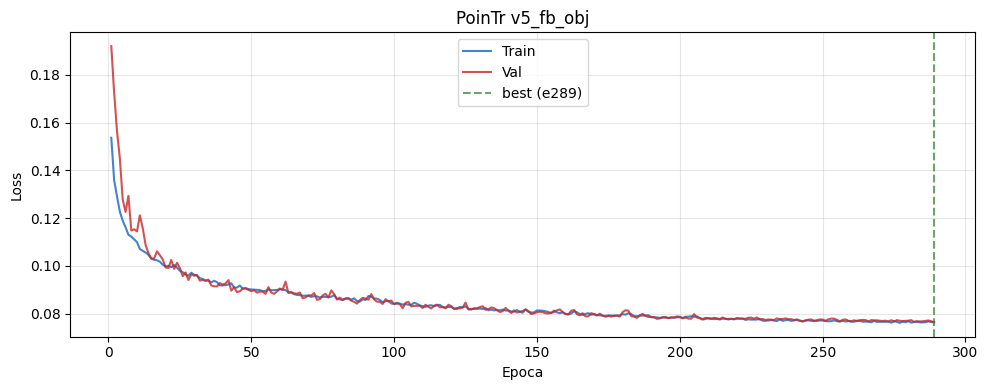

Mejor epoch: 289 | val loss: 0.076467


In [9]:
# ── CELDA 10: Curvas de aprendizaje ────────────────────────────
import matplotlib.pyplot as plt, torch
from pathlib import Path

ckpt_path=f'E3/checkpoints_pointr_{VERSION}/best.pt'
if not Path(ckpt_path).exists():
    DRIVE='/content/drive/MyDrive'
    ckpt_path=f'{DRIVE}/Datos_E2_E3/E3/Raquel/modelos/{VERSION}/best.pt'
ck=torch.load(ckpt_path,map_location='cpu',weights_only=False)

fig,ax=plt.subplots(figsize=(10,4))
eps=range(1,len(ck['train_losses'])+1)
ax.plot(eps,ck['train_losses'],label='Train',color='#1565C0',alpha=0.8)
ax.plot(eps,ck['val_losses'],  label='Val',  color='#C62828',alpha=0.8)
ax.axvline(ck['epoch'],color='#2E7D32',linestyle='--',alpha=0.7,label=f'best (e{ck["epoch"]})')
ax.set_xlabel('Epoca'); ax.set_ylabel('Loss'); ax.set_title(f'PoinTr {VERSION}')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout()
res_local=Path(f'E3/resultados_pointr_{VERSION}'); res_local.mkdir(exist_ok=True)
plt.savefig(res_local/'curvas.png',dpi=100,bbox_inches='tight')
plt.show()
print(f'Mejor epoch: {ck["epoch"]} | val loss: {min(ck["val_losses"]):.6f}')